# EDA

In [14]:
import pandas as pd
import os
import json
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


DATA_PATH = 'data/MovieSummaries/'

In [ ]:
def explore_metadata():
    # 1. Analisi dei metadati dei FILM
    # Serve per capire i generi cinematografici
    movie_cols = ['wiki_id', 'freebase_id', 'name', 'release_date', 'revenue', 'runtime', 'languages', 'countries', 'genres'] # poi sotto li assegno ai pezzetti
    movies = pd.read_csv(os.path.join(DATA_PATH, 'movie.metadata.tsv'), sep='\t', names=movie_cols, header=None)
    
    print(f"--- Movies Metadata (# movies: {len(movies)}) ---")
    # I generi sono in formato JSON string, vediamone uno
    sample_genre = movies['genres'].iloc[0] # prende il genere della prima linea
    print(f"ex genres format: {sample_genre}")
    
    # 2. Analisi dei metadati dei PERSONAGGI
    char_cols = ['wiki_id', 'freebase_id', 'release_date', 'char_name', 'actor_dob', 'actor_gender', 'actor_height', 'actor_ethnicity', 'actor_name', 'actor_age', 'freebase_char_id', 'freebase_actor_id', 'freebase_id_2']



    chars = pd.read_csv(os.path.join(DATA_PATH, 'character.metadata.tsv'), sep='\t', names=char_cols, header=None)
    
    print(f"\n--- Characters Metadata (# characters: {len(chars)}) ---")
    print(f"gender distribution :\n{chars['actor_gender'].value_counts(dropna=False)}") # raggruppo per actor genere

    # 3. Analisi delle TRAME
    plots = pd.read_csv(os.path.join(DATA_PATH, 'plot_summaries.txt'), sep='\t', names=['wiki_id', 'plot'], header=None)
    print(f"\n--- Plot Summaries ---")
    print(f"average length of plots (in char): {plots['plot'].str.len().mean():.2f}")

    return movies, chars, plots

movies, chars, plots = explore_metadata()

--- Movies Metadata (# movies: 81741) ---
ex genres format: {"/m/01jfsb": "Thriller", "/m/06n90": "Science Fiction", "/m/03npn": "Horror", "/m/03k9fj": "Adventure", "/m/0fdjb": "Supernatural", "/m/02kdv5l": "Action", "/m/09zvmj": "Space western"}

--- Characters Metadata (# characters: 450669) ---
gender distribution :
actor_gender
M      270257
F      134803
NaN     45609
Name: count, dtype: int64

--- Plot Summaries ---
average length of plots (in char): 1784.03


In [11]:
def explore_trope():
    # absent_minded_professor	{"char": "Professor Philip Brainard", "movie": "Flubber", "id": "/m/0jy9q0", "actor": "Robin Williams"}
    trope_cols = ['trope_name', 'char_details'] # qui inserirai i nomi delle colonne
    trope = pd.read_csv(os.path.join(DATA_PATH, 'tvtropes.clusters.txt'), sep='\t', names=trope_cols)
    
    # char details -> json format
    import json

    def parse_json(x):
        try:
            d = json.loads(x)
            return pd.Series([d.get('char'), d.get('movie'), d.get('id'), d.get('actor')])
        except:
            return pd.Series([None, None, None])
        
    trope[['char', 'movie', 'id', 'actor']] = trope['char_details'].apply(parse_json)

    #count tropes
    print(f"numers of unique tropes: {len(trope['trope_name'].unique())}")

    #most frequent tropes
    print(f" most frequent: {trope['trope_name'].value_counts().head(10)}")

explore_trope()


numers of unique tropes: 72
 most frequent: trope_name
crazy_jealous_guy              25
corrupt_corporate_executive    23
byronic_hero                   17
psycho_for_hire                16
father_to_his_men              15
stoner                         13
brainless_beauty               12
master_swordsman               12
dumb_blonde                    11
slacker                        11
Name: count, dtype: int64


In dataPreparation i created a file -> at_tropes_with_gender.csv
these are the columns: trope_name,freebase_char_id,char_name,gender,actor_name,age

# distribution of tropes and ages and gender

In [2]:
df = pd.read_csv("data/processed/at_tropes_with_gender.csv")

In [5]:
# filter out record without gender or age
df_copy = df.dropna(subset=['age', 'gender']).copy()

# and outliers
df_copy = df_copy[(df_copy['age']>0) & (df_copy['age']<100)]

In [6]:
#bins
bins = [0, 18, 30, 40, 50, 60, 100]
labels = ['0-18', '19-30', '31-40', '41-50', '51-60', '60+']
df_copy['age_bin'] = pd.cut(df_copy['age'], bins=bins, labels=labels)

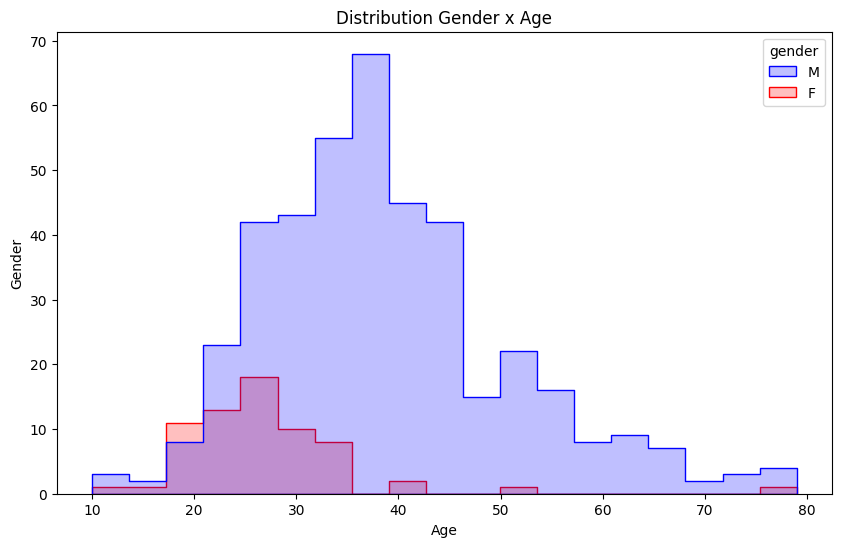

In [11]:
# plot distribution
plt.figure(figsize=(10,6))
sns.histplot(data = df_copy, x='age', hue='gender', element='step', palette={'M': 'blue', 'F': 'red'})
plt.title("Distribution Gender x Age")
plt.xlabel("Age")
plt.ylabel("Gender")
plt.show()

Now i introduced tropes
I want something like : for 18-30 men -> surf dude; for 18-30 women -> girly girl

In [13]:

def top_tropes_by_age_gender(age_group, gender, n=5):
    subset = df_copy[(df_copy['age_bin'] == age_group) & (df_copy['gender'] == gender)]
    return subset['trope_name'].value_counts().head(n)
# Qui la funzione crea una "sottotabella" (subset).
# Usa l'operatore & (AND logico) per tenere solo le righe che soddisfano entrambe le condizioni: devono appartenere a quella fascia d'età E devono essere di quel genere.

# ['0-18', '19-30', '31-40', '41-50', '51-60', '60+']
print(f"Top tropes F (0-18 y):\n{top_tropes_by_age_gender('0-18', 'F')}\n")
print(f"Top tropes M (0-18y):\n{top_tropes_by_age_gender('0-18', 'M')}\n")

print(f"Top tropes F (19-30 y):\n{top_tropes_by_age_gender('19-30', 'F')}\n")
print(f"Top tropes M (19-30 y):\n{top_tropes_by_age_gender('19-30', 'M')}\n")

print(f"Top tropes F (31-40 y):\n{top_tropes_by_age_gender('31-40', 'F')}\n")
print(f"Top tropes M (31-40 y):\n{top_tropes_by_age_gender('31-40', 'M')}\n")

print(f"Top tropes F (41-50 y):\n{top_tropes_by_age_gender('41-50', 'F')}\n")
print(f"Top tropes M (41-50 y):\n{top_tropes_by_age_gender('41-50', 'M')}\n")

print(f"Top tropes F (51-60 y):\n{top_tropes_by_age_gender('51-60', 'F')}\n")
print(f"Top tropes M (51-60 y):\n{top_tropes_by_age_gender('51-60', 'M')}\n")

print(f"Top tropes F (60+ y):\n{top_tropes_by_age_gender('60+', 'F')}\n")
print(f"Top tropes M (60+ y):\n{top_tropes_by_age_gender('60+', 'M')}\n")

Top tropes F (0-18 y):
trope_name
ditz              1
junkie_prophet    1
storyteller       1
valley_girl       1
Name: count, dtype: int64

Top tropes M (0-18y):
trope_name
arrogant_kungfu_guy    1
big_man_on_campus      1
bully                  1
child_prodigy          1
gadgeteer_genius       1
Name: count, dtype: int64

Top tropes F (19-30 y):
trope_name
dumb_blonde         8
final_girl          6
valley_girl         5
brainless_beauty    4
broken_bird         4
Name: count, dtype: int64

Top tropes M (19-30 y):
trope_name
stoner               9
surfer_dude          8
big_man_on_campus    6
jerk_jock            6
slacker              6
Name: count, dtype: int64

Top tropes F (31-40 y):
trope_name
brainless_beauty      3
chanteuse             3
dumb_blonde           2
heartbroken_badass    1
slacker               1
Name: count, dtype: int64

Top tropes M (31-40 y):
trope_name
crazy_jealous_guy              10
psycho_for_hire                 9
corrupt_corporate_executive     8
byroni

# EDA character & movies

In [22]:
import pandas as pd
import os

# Definiamo i nomi delle colonne ufficiali del dataset CMU
char_cols = [
    'wiki_id', 
    'freebase_movie_id', 
    'release_date', 
    'char_name', 
    'actor_dob', 
    'actor_gender', 
    'actor_height', 
    'actor_ethnicity', 
    'actor_name', 
    'actor_age', 
    'freebase_char_id', 
    'freebase_actor_id', 
    'freebase_id_2'
]

# Caricamento corretto
df_char = pd.read_csv(
    "data/MovieSummaries/character.metadata.tsv", 
    sep='\t',          # Fondamentale per i file .tsv
    header=None,       # Dice a pandas che non ci sono titoli nella prima riga
    names=char_cols    # Assegna i nomi che abbiamo definito sopra
)

print(f"Caricati {len(df_char)} personaggi.")
display(df_char.head())

Caricati 450669 personaggi.


,wiki_id,freebase_movie_id,release_date,char_name,actor_dob,actor_gender,actor_height,actor_ethnicity,actor_name,actor_age,freebase_char_id,freebase_actor_id,freebase_id_2
0,975900,/m/03vyhn,2001-08-24,Akooshay,1958-08-26,F,1.620,NaN,Wanda De Jesus,42.0,/m/0bgchxw,/m/0bgcj3x,/m/03wcfv7
1,975900,/m/03vyhn,2001-08-24,Lieutenant Melanie Ballard,1974-08-15,F,1.780,/m/044038p,Natasha Henstridge,27.0,/m/0jys3m,/m/0bgchn4,/m/0346l4
2,975900,/m/03vyhn,2001-08-24,Desolation Williams,1969-06-15,M,1.727,/m/0x67,Ice Cube,32.0,/m/0jys3g,/m/0bgchn_,/m/01vw26l
3,975900,/m/03vyhn,2001-08-24,Sgt Jericho Butler,1967-09-12,M,1.750,NaN,Jason Statham,33.0,/m/02vchl6,/m/0bgchnq,/m/034hyc
4,975900,/m/03vyhn,2001-08-24,Bashira Kincaid,1977-09-25,F,1.650,NaN,Clea DuVall,23.0,/m/02vbb3r,/m/0bgchp9,/m/01y9xg


In [25]:
df_char["actor_gender"].value_counts()

actor_gender
M    270257
F    134803
Name: count, dtype: int64

and movies. NB a single movie can has more than one genres

In [26]:
movie_cols = ['wiki_id', 'freebase_id', 'name', 'release_date', 'revenue', 'runtime', 'languages', 'countries', 'genres'] # poi sotto li assegno ai pezzetti
df_movie = pd.read_csv(os.path.join(DATA_PATH, 'movie.metadata.tsv'), sep='\t', names=movie_cols, header=None)

In [28]:
df_movie[['freebase_id', 'name']].head(5)

,freebase_id,name
0,/m/03vyhn,Ghosts of Mars
1,/m/08yl5d,Getting Away with Murder: The JonBenét Ramsey ...
2,/m/0crgdbh,Brun bitter
3,/m/0285_cd,White Of The Eye
4,/m/01mrr1,A Woman in Flames


In datapreparation i created a file (char and movies) with:
['wiki_id', 'freebase_movie_id', 'release_date', 'char_name', 'actor_dob', 'actor_gender', 'actor_height', 'actor_ethnicity', 'actor_name', 'actor_age', 'freebase_char_id', 'freebase_actor_id', 'freebase_id_2', 'movie_name']
Now we can see the name of the movie in the char 's file

In [29]:
df = pd.read_csv("data/processed/char_and_movie.csv")

In [38]:
subset = df[['actor_gender', 'movie_name']].dropna()

Distribuzione di genere:
actor_gender
M    270257
F    134803
Name: count, dtype: int64


/var/folders/_6/l87gfk2514nc1qmjb0tz_wp80000gn/T/ipykernel_2774/286772464.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='actor_gender', palette={'M': 'tab:blue', 'F': 'tab:red'})


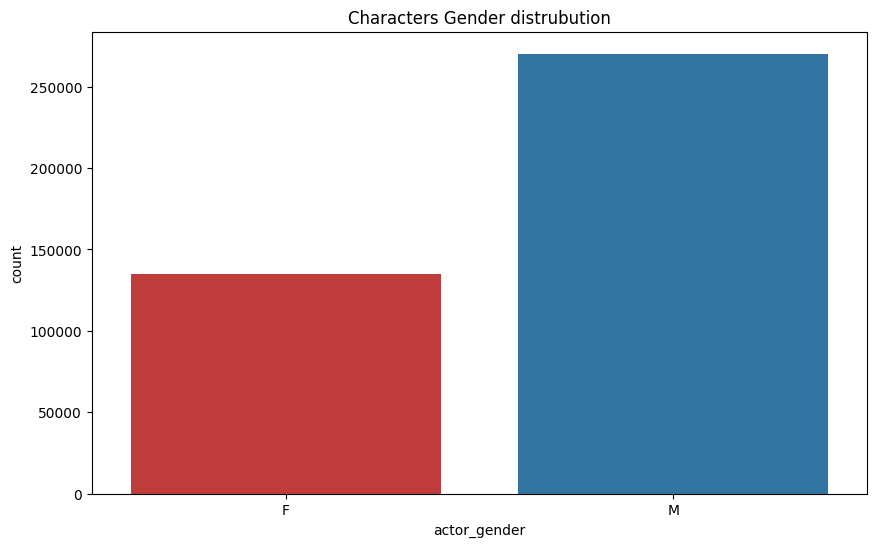

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

# Conteggio semplice
# nb stai contando i personaggi, non gli attori. Lo stesso attore può essere contato più volte perché interpreta personaggi diversi
gender_counts = df['actor_gender'].value_counts()
print(f"Distribuzione di genere:\n{gender_counts}")

# Grafico a torta o a barre
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='actor_gender', palette={'M': 'tab:blue', 'F': 'tab:red'})
plt.title('Characters Gender distrubution')
plt.show()

/var/folders/_6/l87gfk2514nc1qmjb0tz_wp80000gn/T/ipykernel_2774/3907951595.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_copy.dropna(subset=['actor_age', 'actor_gender']),


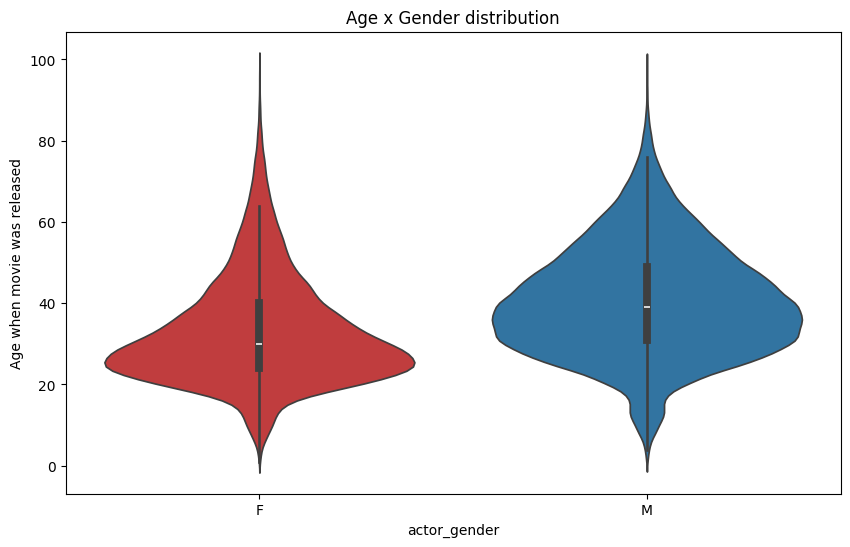

In [50]:
# Distribuzione dell'età (Violin Plot)
df_copy = df.dropna(subset=['actor_age', 'actor_gender']).copy()
# and outliers
df_copy = df_copy[(df_copy['actor_age']>0) & (df_copy['actor_age']<100)]

plt.figure(figsize=(10, 6))
sns.violinplot(data=df_copy.dropna(subset=['actor_age', 'actor_gender']), 
               x='actor_gender', y='actor_age', palette={'M': 'tab:blue', 'F': 'tab:red'})
plt.title('Age x Gender distribution')
plt.ylabel('Age when movie was released')
plt.show()

In [53]:
# # Creiamo una tabella pivot film/genere
# pivot_gender = df.groupby(['movie_name', 'actor_gender']).size().unstack(fill_value=0)

# # Calcoliamo la percentuale di donne
# pivot_gender['total'] = pivot_gender['M'] + pivot_gender['F']
# pivot_gender['pct_female'] = (pivot_gender['F'] / pivot_gender['total']) * 100

# print("Film con la percentuale più BASSA di donne (minimo 5 personaggi):")
# print(pivot_gender[pivot_gender['total'] >= 5].sort_values('pct_female').head(10))

# print("\nFilm con la percentuale più ALTA di donne (minimo 5 personaggi):")
# print(pivot_gender[pivot_gender['total'] >= 5].sort_values('pct_female', ascending=False).head(10))

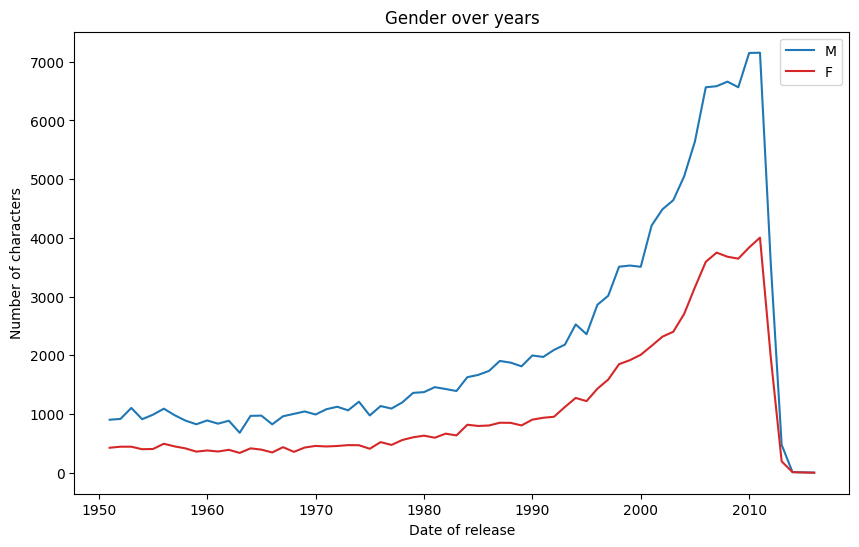

In [54]:
# Estraiamo l'anno dalla data di rilascio
df['year'] = pd.to_datetime(df['release_date'], errors='coerce').dt.year

# Filtriamo per anni significativi (es. dopo il 1950)
yearly_gender = df[df['year'] > 1950].groupby(['year', 'actor_gender']).size().unstack(fill_value=0)

# Grafico a linee
plt.figure(figsize=(10, 6))
plt.plot(yearly_gender.index, yearly_gender['M'], label='M', color='tab:blue')
plt.plot(yearly_gender.index, yearly_gender['F'], label='F', color='tab:red')
plt.title('Gender over years')
plt.xlabel('Date of release')
plt.ylabel('Number of characters')
plt.legend()
plt.show()

# NLP on plots